In [130]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

#### Correzzioni degli offset.


Nella correzione Lente 1, offset_LENTE1_A e offset_LENTE1_B rappresentano rispettivamente la distanza tra l'asse del carrellino e V e la distanza tra l asse del carrellino e V'.

VV_LENTE1 è la distanza VV' data come specifica della lente (c'è una piccola incongruenza dato che la somma di offset_A e offset_B non è uguale a VV).

In offset_LENTE1_q e offset_LENTE1_p il primo e secondo termine se sommati definiscono l'offset dell'asse della lente (che non combacia con l'asse del carrellino) mentre VV/3 rappresenta l'offset dovuto alla distanza tra asse della lente e i piani principali.

In offset_LENTE2 avremmo dovuto applicare lo stesso concetto ma, non avendo a disposizione una misura paragonabile a offset_A e offset_B ma per la lente 2, si preferisce approssimare il centro della lente come coincidente al centro del carrellino.

In [131]:
#Correzione distanza oggetto:
SBARRETTA = [82.0, 0.5/np.sqrt(24)]
SCHERMO = [75.0, 0.3/np.sqrt(24)]
CARRELLINO = [25.4, 0.3/np.sqrt(12)]
OGGETTO = [35.0, 0.5/np.sqrt(24)]
offset_OGGETTO = [SBARRETTA[0] + SCHERMO[0]/2 - CARRELLINO[0]/2 - OGGETTO[0],
                  f.propaga_incertezza(
                        "x + y - z/2 - w",
                        ["x","y","z","w"],
                        [SBARRETTA[0],SCHERMO[0],CARRELLINO[0],OGGETTO[0]],
                        [SBARRETTA[1],SCHERMO[1],CARRELLINO[1],OGGETTO[1]],
                        ritorno=True
                  )[0]
                  ]

print(f"offset_OGGETTO = {offset_OGGETTO[0]} ± {offset_OGGETTO[1]}")

#Correzione CCD:
PIANO_IMMAGINE = [9.0, 0.3/np.sqrt(12)]
CCD = [6.0, 0.3/np.sqrt(12)]
offset_CCD = [CARRELLINO[0]/2 + PIANO_IMMAGINE[0] - CCD[0],
                f.propaga_incertezza(
                        "x/2 + y - z",
                        ["x","y","z"],
                        [CARRELLINO[0],PIANO_IMMAGINE[0],CCD[0]],
                        [CARRELLINO[1],PIANO_IMMAGINE[1],CCD[1]],
                        ritorno=True
                )[0]
                ]

print(f"offset_CCD = {offset_CCD[0]} ± {offset_CCD[1]}")
print("")

#Correzione Lente 1:
PA = [69.0, 0.5/np.sqrt(24)]
PB = [77.0, 0.5/np.sqrt(24)]
LENTE1 = [170.5, 0.5/np.sqrt(24)]
offset_LENTE1_A = [CARRELLINO[0] + LENTE1[0] - PA[0] - SCHERMO[0]/2 - SBARRETTA[0],
                   f.propaga_incertezza(
                       "x + y - z - w/2 - q",
                       ["x","y","z","w","q"],
                       [CARRELLINO[0],LENTE1[0],PA[0],SCHERMO[0],SBARRETTA[0]],
                       [CARRELLINO[1],LENTE1[1],PA[1],SCHERMO[1],SBARRETTA[1]],
                       ritorno=True
                   )[0]
                   ]

print(f"offset_LENTE1_A = {offset_LENTE1_A[0]} ± {offset_LENTE1_A[1]}")

offset_LENTE1_B = [CARRELLINO[0] + LENTE1[0] - PB[0] - SCHERMO[0]/2 - SBARRETTA[0],
                   f.propaga_incertezza(
                       "x + y - z - w/2 - q",
                       ["x","y","z","w","q"],
                       [CARRELLINO[0],LENTE1[0],PB[0],SCHERMO[0],SBARRETTA[0]],
                       [CARRELLINO[1],LENTE1[1],PB[1],SCHERMO[1],SBARRETTA[1]],
                       ritorno=True
                   )[0]
                   ]

print(f"offset_LENTE1_B = {offset_LENTE1_B[0]} ± {offset_LENTE1_B[1]}")

VV_LENTE1 = [offset_LENTE1_A[0] + offset_LENTE1_B[0],
                   f.propaga_incertezza(
                       "x + y",
                       ["x","y"],
                       [offset_LENTE1_A[0],offset_LENTE1_B[0]],
                       [offset_LENTE1_A[1],offset_LENTE1_B[1]],
                       ritorno=True
                   )[0]
                   ]

print(f"VV_LENTE1 = {VV_LENTE1[0]} ± {VV_LENTE1[1]}")

VV_LENTE1_real = [7.2, 0.1]

print(f"VV_LENTE1_real = {VV_LENTE1_real[0]} ± {VV_LENTE1_real[1]}")
print(f"Indice di compatibilità tra i due valori di VV' = {f.compatibilita(VV_LENTE1[0], VV_LENTE1[1], VV_LENTE1_real[0], VV_LENTE1_real[1])}")

offset_LENTE1_p = [CARRELLINO[0]/2 - (offset_LENTE1_A[0] - offset_LENTE1_B[0])/2 - (VV_LENTE1_real[0]/3)/2,
                   f.propaga_incertezza(
                       "x/2 - (y - z)/2 - w/6",
                       ["x","y","z","w"],
                       [CARRELLINO[0], offset_LENTE1_A[0], offset_LENTE1_B[0], VV_LENTE1_real[0]],
                       [CARRELLINO[1], offset_LENTE1_A[1], offset_LENTE1_B[1], VV_LENTE1_real[1]],
                       ritorno=True
                   )[0]
                ]

print(f"offset_LENTE1_p = {offset_LENTE1_p[0]} ± {offset_LENTE1_p[1]}")

offset_LENTE1_q = [CARRELLINO[0]/2 - (offset_LENTE1_A[0] - offset_LENTE1_B[0])/2 + (VV_LENTE1_real[0]/3)/2,
                   f.propaga_incertezza(
                       "x/2 - (y - z)/2 + w/6",
                       ["x","y","z","w"],
                       [CARRELLINO[0], offset_LENTE1_A[0], offset_LENTE1_B[0], VV_LENTE1_real[0]],
                       [CARRELLINO[1], offset_LENTE1_A[1], offset_LENTE1_B[1], VV_LENTE1_real[1]],
                       ritorno=True
                   )[0]
                ]

print(f"offset_LENTE1_q = {offset_LENTE1_q[0]} ± {offset_LENTE1_q[1]}")


"""
Correzione Lente 2:
offset_LENTE2_A = 0
offset_LENTE2_B = 0
VV_LENTE2 = 10.1
offset_LENTE1_p = 25.4/2 - (offset_LENTE1_A - offset_LENTE1_B)/2 - (VV_LENTE1/3)/2
offset_LENTE1_q = 25.4/2 - (offset_LENTE1_A - offset_LENTE1_B)/2 + (VV_LENTE1/3)/2
"""

#Correzione dei dati del secondo giorno (in realtà terzo) per la rotazione della mascherina
offset_GIORNO2 = - 7
#Lunghezza totale (per Bessel)
lunghezza = [561.0, 0.5/np.sqrt(24)]

offset_OGGETTO = 71.8 ± 0.16266017746619282
offset_CCD = 15.7 ± 0.1299038105676658

offset_LENTE1_A = 7.400000000000006 ± 0.19921721813136536
offset_LENTE1_B = -0.5999999999999943 ± 0.19921721813136536
VV_LENTE1 = 6.800000000000011 ± 0.28173569173961616
VV_LENTE1_real = 7.2 ± 0.1
Indice di compatibilità tra i due valori di VV' = 1.3379872160113078
offset_LENTE1_p = 7.499999999999999 ± 0.14831226442131404
offset_LENTE1_q = 9.899999999999999 ± 0.14831226442131404


Il valore "-7" è assunto senza errore, dato dalla Sada.

Viene stimata la compatibilità tra VV' e la somma tra offset_A e offset_B.

Le misure date nelle specifiche tecniche quali CARRELLINO o simili hanno incertezza data da la risoluzione in pollici convertita in mm poi divisa per radice di 12 (considerando quindi una distribuzione uniforme).

# 1. Punti Coniugati


In [132]:
metodo = "Coniugati"

### 1.1 Lettura

In [133]:
def nome (stringa, cartella):
    """
    Estrae il nome dal titolo di ogni file input letto
    """
    
    stringa_nuova = stringa.replace(f'./Data/{cartella}/dati_','').replace('.csv','')
    return stringa_nuova

In [134]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data1 = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data1[nome(input_file, metodo)] = {
        "immagine": letti["immagine"],
        "lente": letti["lente"],
    }

### 1.2 Analisi

$$
Y = \frac{1}{f} - X
$$

$$
\frac{1}{x_{lente}} = \frac{1}{f} - \frac{1}{x_{immagine}}
$$

Le incertezze usate sono state stimate come risoluzione (0.5mm) fratto il quadrato della misura: questo è dovuto alla propagazione delle incertezze per il reciproco di un valore.

In [135]:
distanze = {}
focali1 = {}

p_err = np.sqrt( (0.5/np.sqrt(24))**2 + offset_OGGETTO[1]**2 + offset_LENTE1_p[1]**2 )
q_err = np.sqrt( (0.5/np.sqrt(24))**2 + (0.5/np.sqrt(24))**2 + offset_OGGETTO[1]**2 + offset_LENTE1_p[1]**2 + offset_LENTE1_q[1]**2 + offset_CCD[1]**2 )


for colore,dati in data1.items():
    if colore=="rosso":
        p = np.array(dati["lente"]) + offset_OGGETTO[0] + offset_GIORNO2 + offset_LENTE1_p[0]
    else:
        p = np.array(dati["lente"]) + offset_OGGETTO[0] + offset_LENTE1_p[0]
    q = np.array(dati["immagine"]) - (np.array(dati["lente"]) + offset_LENTE1_q[0]) + offset_CCD[0]

    anal = f.elaborato(1/q, 1/p, 
                        p_err / (p*p),
                        "elaborato_coniugati.txt", 0, 
                        vsx = q_err / (q*q),
                        ritorno = True )

    distanze[colore] = {
        "p" : p,
        "q" : q,
    }

    focali1[colore] = {
        "f" : 1/anal[0],
        "sf" : anal[2]/anal[0]**2
    }


Elaborazione serie 1
	Incertezze x variabili
	Incertezze y variabili
	Minimi quadrati 3

Elaborazione serie 1
	Incertezze x variabili
	Incertezze y variabili
	Minimi quadrati 3

Elaborazione serie 1
	Incertezze x variabili
	Incertezze y variabili
	Minimi quadrati 3


### 1.3 Grafici

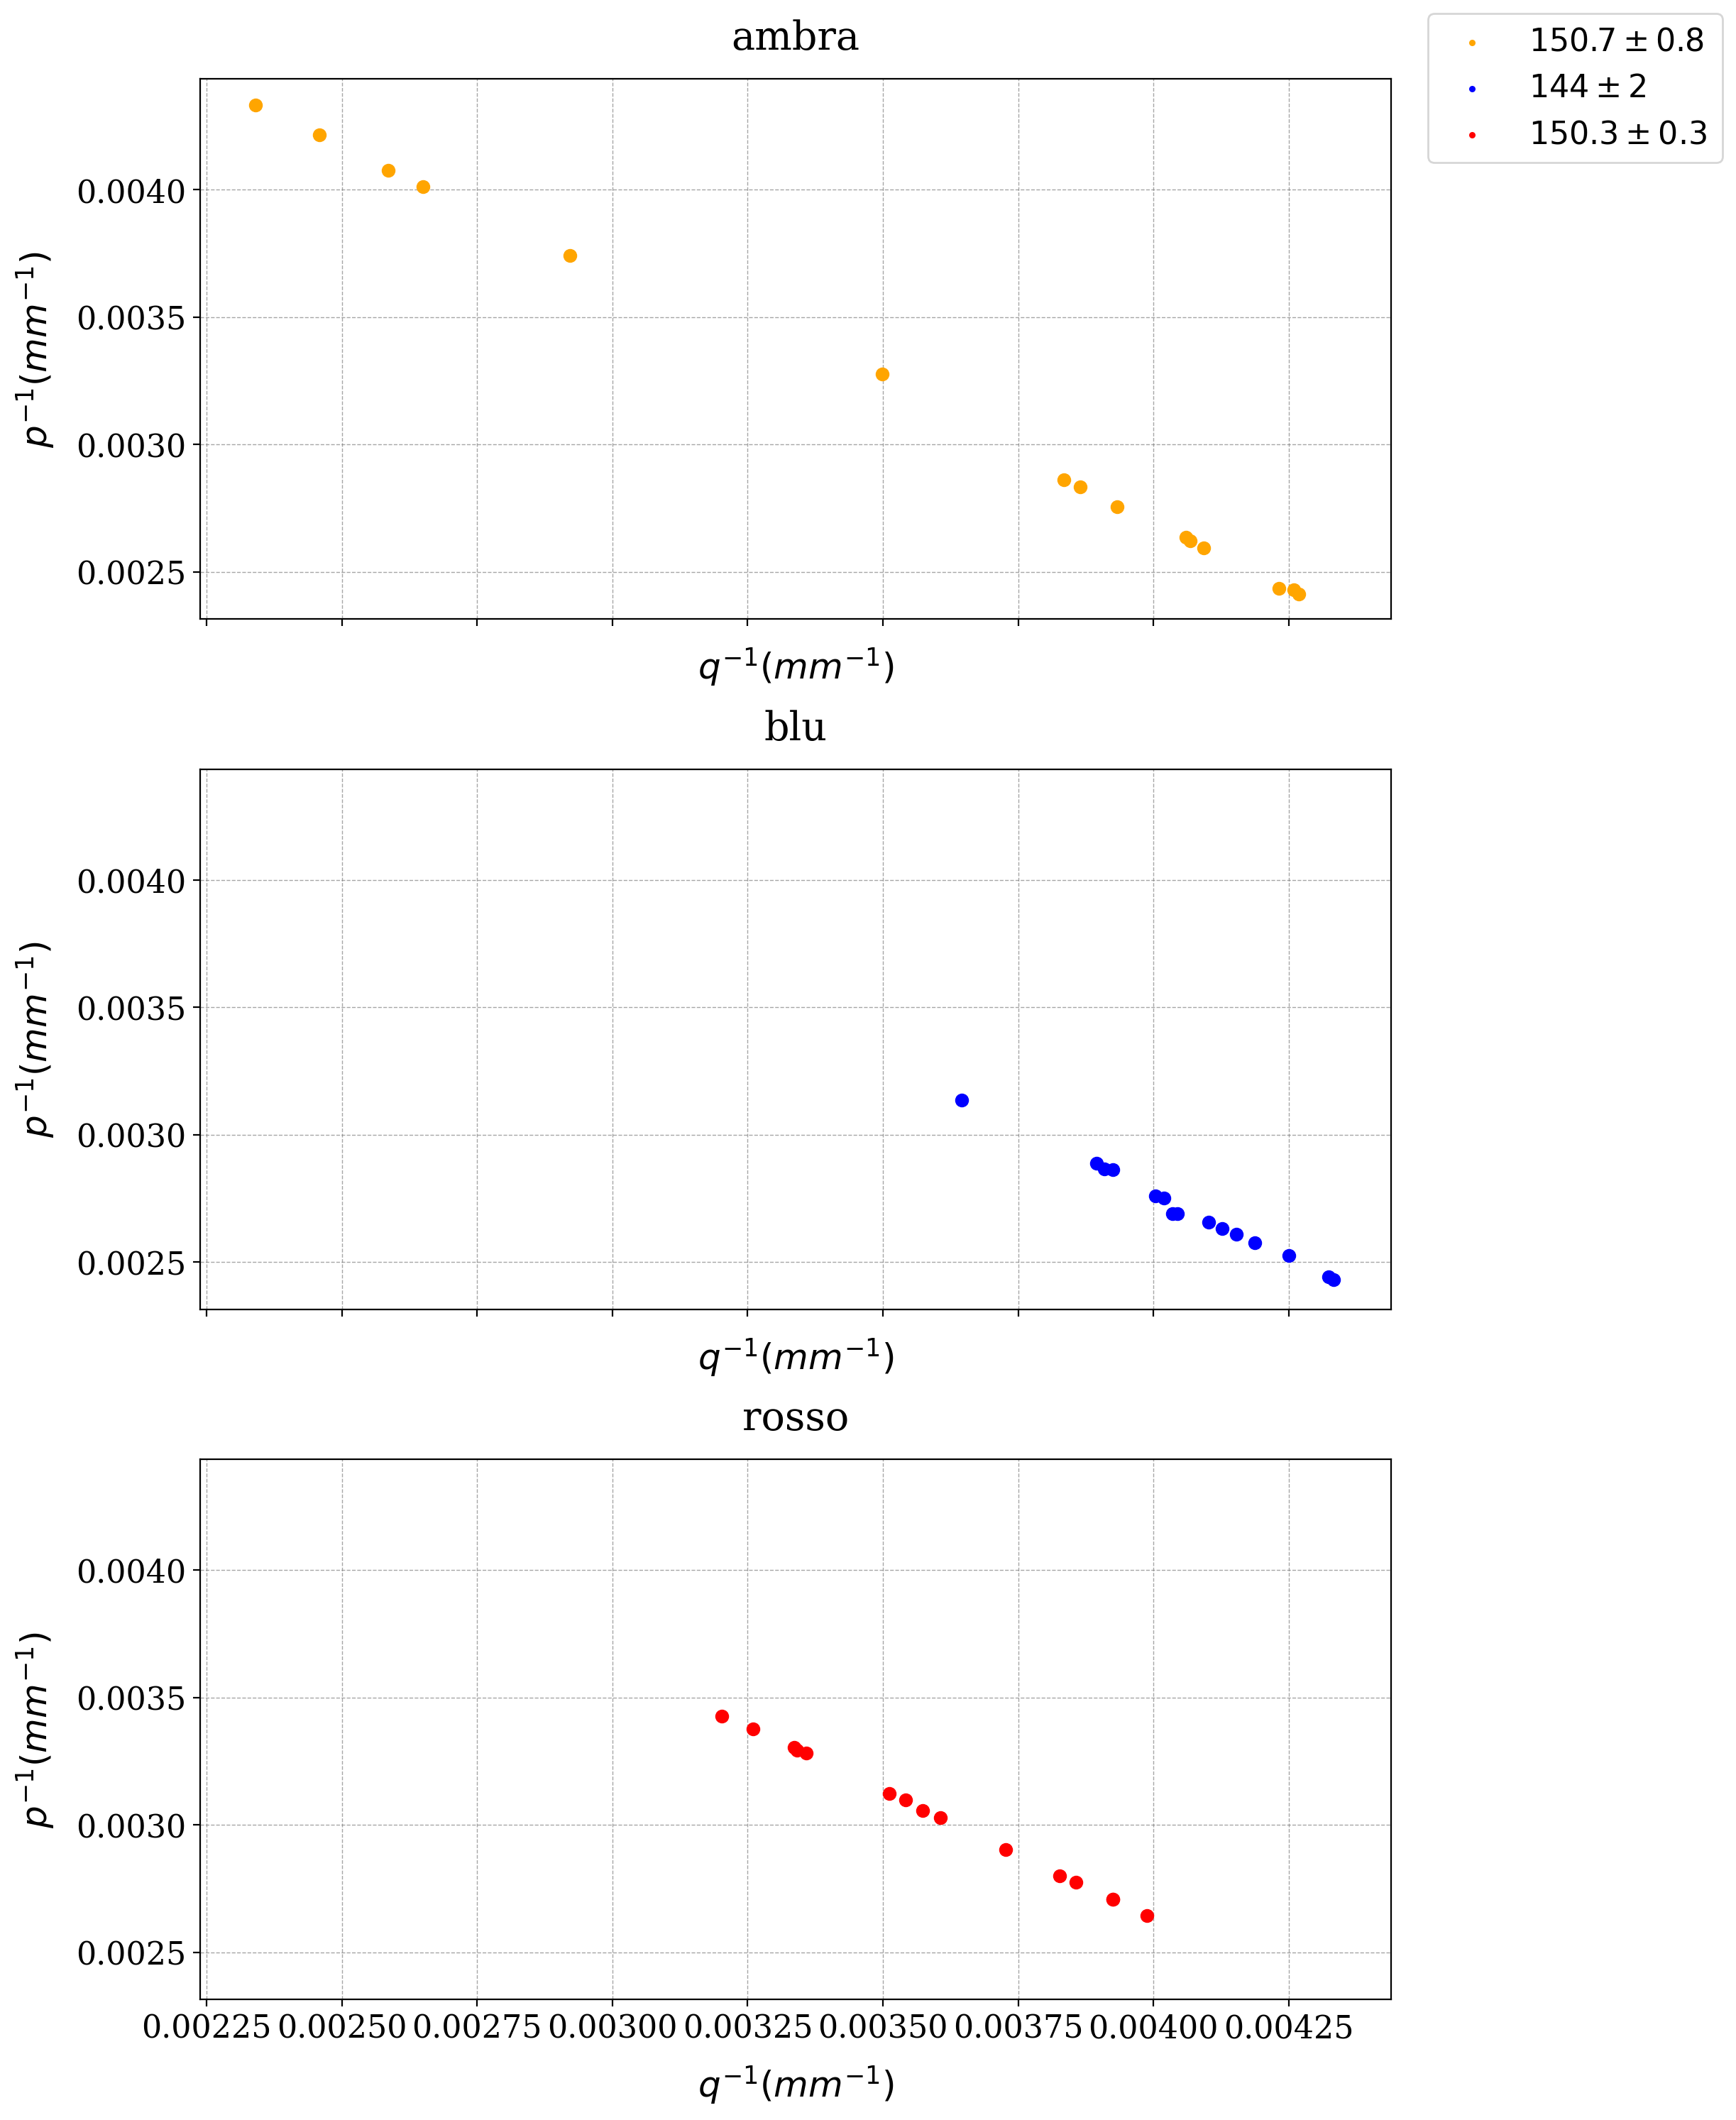

In [ ]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5), sharex=True, sharey=True)

ax = axes

titolo = "Test"

for i, (input_file, distanza, focali) in enumerate(zip(input_files, distanze.values(), focali1.values())):

    ax = axes[i]

    titolo = nome(input_file, metodo)
    if i == 0 : colore = "orange"
    elif i == 1 : colore = "blue"
    elif i == 2 : colore = "red"

    p = distanza["p"]
    q = distanza["q"]

    ax.errorbar(1/q, 1/p, xerr = q_err / (q*q) , yerr = p_err / (p*p), color=colore, fmt = 'o')

    stringa_f = gf.formatta_errore(focali["f"],focali["sf"])

    gf.parametri_grafico(ax, titolo, "$q^{-1}(mm^{-1})$", "$p^{-1}(mm^{-1})$")
    gf.descrizione_legenda(ax, stringa_f, color=colore)
gf.salva_grafico(fig, "grafici_coniugati.pdf")

# 2. Bessel

In [137]:
metodo = "Bessel"

### 2.1 Lettura

In [138]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data2 = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data2[nome(input_file, metodo)] = {
        "pl+": letti["pl+"],
        "pl-": letti["pl-"],
    }

### 2.2 Analisi

In [139]:
focali2 = {}

L = lunghezza[0] + offset_OGGETTO[0] + offset_CCD[0]
L0 = L
L_err = np.sqrt( lunghezza[1]**2 + offset_OGGETTO[1]**2 + offset_CCD[1]**2 )

for colore,dati in data2.items():

    if colore=="rosso" : L = L0 + offset_GIORNO2

    pl_piu = np.mean(np.array(dati["pl+"]))
    pl_meno = np.mean(np.array(dati["pl-"]))
    s_pl_piu = f.s_media(dati["pl+"])
    s_pl_meno = f.s_media(dati["pl-"])
    ritorno = f.propaga_incertezza("(L**2 - (pl_piu - pl_meno)**2) / (4 * L)", ["L","pl_piu","pl_meno"],
                     valori = [L, pl_piu, pl_meno],
                     incertezze = [L_err, s_pl_piu, s_pl_meno],
                     ritorno = True)
    focali2[colore] = {
        "f" : (L**2 - (pl_piu - pl_meno)**2) / (4 * L),
        "sf" : ritorno[0],
        }
L = L0

In [140]:
z_scores = {}

for colore in focali1.keys():
    f1 = focali1[colore]["f"]
    sf1 = focali1[colore]["sf"]
    f2 = focali2[colore]["f"]
    sf2 = focali2[colore]["sf"]

    z = f.compatibilita(f1, sf1, f2, sf2)
    z_scores[colore] = z


In [ ]:
def crea_file_riassunto(focali1, focali2, z_scores, nomefile="compatibilità_focali.txt"):
    with open(nomefile, "w") as f:
        f.write("RIASSUNTO MISURE FOCALE\n")
        f.write("========================\n\n")

        for colore in sorted(focali1.keys()):
            f1 = focali1[colore]["f"]
            sf1 = focali1[colore]["sf"]
            f2 = focali2[colore]["f"]
            sf2 = focali2[colore]["sf"]
            z = z_scores[colore]

            f.write(f"Colore: {colore}\n")
            f.write(f"  Coniugati: {gf.formatta_errore(f1, sf1, 'mm',txt=True)}\n")
            f.write(f"  Bessel:    {gf.formatta_errore(f2, sf2, 'mm',txt=True)}\n")
            f.write(f"  Indice di Compatibilità:   {z:.3f}\n")
            f.write("\n")

    print(f"File '{nomefile}' creato senza fare troppe scene.")

crea_file_riassunto(focali1, focali2, z_scores)

File 'compatibilità_focali.txt' creato senza fare troppe scene.


# 3. Aberrazione

In [51]:
metodo = "Aberrazione"

### 3.1 Lettura

In [52]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data3 = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data3[nome(input_file, metodo)] = {
        "parassiale": letti["parassiale"],
        "marginale": letti["marginale"],
    }

### 3.2 Analisi

In [53]:
aberrazione_sferica = {}

for colore,dati in data3.items():

    f_marginale = np.mean(np.array(dati["marginale"]))
    f_parassiale = np.mean(np.array(dati["parassiale"]))
    s_f_marginale = f.s_media(dati["marginale"])
    s_f_parassiale = f.s_media(dati["parassiale"])
    ritorno = f.propaga_incertezza("f_parassiale - f_marginale", ["f_parassiale", "f_marginale"],
                     valori = [f_parassiale, f_marginale],
                     incertezze = [s_f_parassiale, s_f_parassiale],
                     ritorno = True)
    aberrazione_sferica[colore] = {
        "aberrazione_sferica" : f_parassiale - f_marginale,
        "s_aberrazione_sferica" : ritorno[0],
        }

In [54]:
gf.display_dizionario(focali1)

In [37]:
aberrazione_longitudinale = {}

for f_c,f_b in zip(focali1.values(),focali2.values()):
    f1 = f_c[0]
    sf1 = f_c[1]
    f2 = f_b[0]
    sf2 = f_b[1]
    f = np.mean(np.array[f1,f2])

KeyError: 0